In [88]:
import re
import matplotlib.pyplot as plt
from pathlib import Path
from difflib import get_close_matches

import pandas as pd
import numpy as np
import json

# LOAD DATA

In [89]:
DATA_DIR = Path("data/processed")          # folder containing the 4 json files
OUT_DIR = Path("data/output")         # where csv/parquet outputs get written

SET_NAME_OVERRIDES = {
    # "pokemonSets set name": "reddit key" or "youtube key prefix",
}

def load_all(data_dir: Path = DATA_DIR):
    ebay = json.load(open(data_dir / "ebay-card-features.json"))
    sets = json.load(open(data_dir / "pokemon-sets.json"))
    reddit = json.load(open(data_dir / "reddit-index.json"))
    youtube = json.load(open(data_dir / "youtube-index.json"))
    return ebay, sets, reddit, youtube

# KEY NORMALIZATION / MATCHING HELPERS

In [90]:
def normalize_key(s: str) -> str:
    """Lowercase, strip, collapse whitespace, drop punctuation for fuzzy matching."""
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9 ]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s


def build_youtube_lookup(youtube: dict) -> dict:
    """Map normalized set name -> youtube key, via prefix match."""
    norm_yt_keys = {normalize_key(k): k for k in youtube}
    lookup = {}
    for norm_yt, orig_yt in norm_yt_keys.items():
        # youtube key is "{set name} {set code}" -> strip trailing token(s)
        # try progressively shorter prefixes
        tokens = norm_yt.split(" ")
        for cut in range(len(tokens) - 1, 0, -1):
            candidate = " ".join(tokens[:cut])
            lookup.setdefault(candidate, orig_yt)
    return lookup


def match_set_name(set_name: str, lookup: dict, all_keys: list, use_fuzzy=True) -> str | None:
    """Resolve a pokemonSets set name to a key in another source's dict."""
    if set_name in SET_NAME_OVERRIDES:
        override = SET_NAME_OVERRIDES[set_name]
        if override in all_keys:
            return override
    norm = normalize_key(set_name)
    if norm in lookup:
        return lookup[norm]
    if set_name in all_keys:  # direct match (e.g. reddit)
        return set_name
    if use_fuzzy:
        norm_all = {normalize_key(k): k for k in all_keys}
        close = get_close_matches(norm, norm_all.keys(), n=1, cutoff=0.85)
        if close:
            return norm_all[close[0]]
    return None


def report_match_coverage(sets: dict, reddit: dict, youtube: dict):
    """Run this first against your real data to see what's matching."""
    yt_lookup = build_youtube_lookup(youtube)
    reddit_keys = list(reddit.keys())
    rows = []
    for set_name in sets:
        yt_match = match_set_name(set_name, yt_lookup, list(youtube.keys()))
        rd_match = match_set_name(set_name, {}, reddit_keys)
        rows.append({"setName": set_name, "youtube_match": yt_match, "reddit_match": rd_match})
    df = pd.DataFrame(rows)
    unmatched = df[df["youtube_match"].isna() | df["reddit_match"].isna()]
    print(f"{len(df)} sets total. {len(unmatched)} with at least one unmatched source:")
    print(unmatched.to_string(index=False))
    return df

# BUILD DFS

In [91]:
def build_sets_df(sets: dict, reddit: dict, youtube: dict) -> pd.DataFrame:
    yt_lookup = build_youtube_lookup(youtube)
    reddit_keys = list(reddit.keys())
    youtube_keys = list(youtube.keys())

    rows = []
    for set_name, s in sets.items():
        row = {
            "setName": set_name,
            "series": s.get("series"),
            "releaseDate": s.get("releaseDate"),
            "boosterPrice": s.get("boosterPrice"),
            "numberOfChases": s.get("numberOfChases"),
            "numberOfHits": s.get("numberOfHits"),
            "chaseRatioOutOfHits": s.get("chaseRatioOutOfHits"),
            "numberOfCards": s.get("numberOfCards"),
        }

        yt_key = match_set_name(set_name, yt_lookup, youtube_keys)
        if yt_key:
            yt = youtube[yt_key]
            row.update({f"yt_{k}": v for k, v in yt.items() if k != "videos"})
            row["youtube_key_matched"] = yt_key
        else:
            row["youtube_key_matched"] = None

        rd_key = match_set_name(set_name, {}, reddit_keys)
        if rd_key:
            rd = reddit[rd_key]
            row.update({f"rd_{k}": v for k, v in rd.items() if k != "posts"})
            row["reddit_key_matched"] = rd_key
        else:
            row["reddit_key_matched"] = None

        rows.append(row)

    df = pd.DataFrame(rows)
    df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
    return df

def build_cards_df(ebay: dict, sets: dict) -> pd.DataFrame:
    rows = []
    for set_name, set_obj in sets.items():
        for rarity_block in set_obj.get("hitsRarities", []):
            rarity = rarity_block.get("rarity")
            pull_rate = rarity_block.get("pullRate")
            cost_per_pull = rarity_block.get("costPerPull")
            for card in rarity_block.get("concernedCards", []):
                row = {
                    "setName": set_name,
                    "cardNumber": card.get("number"),
                    "cardName": card.get("name"),
                    "rarity": rarity,
                    "pullRate": pull_rate,
                    "costPerPull": cost_per_pull,
                    "specificCardPullRate": rarity_block.get("specificCardPullRate"),
                    "isChase": card.get("isChase"),
                    "isPromo": card.get("isPromo"),
                    "isPokemon": card.get("isPokemon"),
                    "pokemonPopularity": card.get("pokemonPopularity"),
                    "priceOnRelease": card.get("priceOnRelease"),
                    "priceEvolution": card.get("priceEvolution"),
                    "ebaySoldVolumeFrom2026": card.get("ebaySoldVolumeFrom2026"),
                }

                ebay_card = ebay.get(set_name, {}).get(card.get("number"), {})
                for k, v in ebay_card.items():
                    if k in ("cardName", "setName", "cardNumber", "conditionCounts",
                             "conditionStatistics", "marketIndexComponents"):
                        continue
                    row[f"ebay_{k}"] = v
                # flatten nested dicts of interest
                for mic_key, mic_val in ebay_card.get("marketIndexComponents", {}).items():
                    row[f"ebay_mic_{mic_key}"] = mic_val

                rows.append(row)

    df = pd.DataFrame(rows)
    return df
 
def build_panel_df(cards_df: pd.DataFrame, sets_df: pd.DataFrame,
                    as_of: pd.Timestamp | None = None) -> pd.DataFrame:
    
    def months_between(earlier: pd.Timestamp, later: pd.Timestamp) -> int:
        """Whole calendar months from `earlier` to `later` (assumes later >= earlier)."""
        return (later.year - earlier.year) * 12 + (later.month - earlier.month)
 
    as_of = pd.Timestamp(as_of) if as_of is not None else pd.Timestamp.today()
    release_lookup = sets_df.set_index("setName")["releaseDate"].to_dict()
 
    records = []
    for _, row in cards_df.iterrows():
        prices = row.get("priceEvolution")
        if not isinstance(prices, list) or len(prices) < 2:
            continue
 
        release_date = release_lookup.get(row["setName"])
        skip = 0
        if pd.notna(release_date):
            months_since_release = months_between(pd.Timestamp(release_date), as_of)
            if months_since_release < 12:
                skip = max(0, len(prices) - months_since_release)
        else:
            # no release date matched -> can't determine age, keep as-is
            pass
 
        trimmed = prices[skip:]
        if len(trimmed) < 2:
            continue
 
        for offset, price in enumerate(trimmed):
            t = skip + offset
            records.append({
                "setName": row["setName"],
                "cardNumber": row["cardNumber"],
                "cardName": row["cardName"],
                "t": t,
                "price": price,
            })
    panel = pd.DataFrame(records)
    panel = panel.sort_values(["setName", "cardNumber", "t"]).reset_index(drop=True)
 
    # --- engineered time-series features per card ---
    grp = panel.groupby(["setName", "cardNumber"])["price"]
    panel["price_lag1"] = grp.shift(1)
    panel["log_price"] = np.log(panel["price"].clip(lower=0.01))
    panel["log_return"] = panel.groupby(["setName", "cardNumber"])["log_price"].diff()
    panel["roll_mean_3"] = grp.transform(lambda s: s.rolling(3, min_periods=1).mean())
    panel["roll_std_3"] = grp.transform(lambda s: s.rolling(3, min_periods=1).std())
    panel["momentum_since_start"] = panel.groupby(["setName", "cardNumber"])["price"].transform(
        lambda s: (s - s.iloc[0]) / s.iloc[0]
    )
 
    # TARGET: next-period log return (what you predict "forward")
    panel["target_next_log_return"] = panel.groupby(["setName", "cardNumber"])["log_return"].shift(-1)
 
    return panel

# ASSEMBLE DATA

In [92]:
def build_model_ready_panel(panel_df: pd.DataFrame, cards_df: pd.DataFrame,
                             sets_df: pd.DataFrame) -> pd.DataFrame:
    card_static_cols = [c for c in cards_df.columns if c not in ("priceEvolution",)]
    merged = panel_df.merge(
        cards_df[card_static_cols], on=["setName", "cardNumber", "cardName"], how="left"
    )
    merged = merged.merge(sets_df, on="setName", how="left")
    return merged

In [93]:
OUT_DIR.mkdir(exist_ok=True, parents=True)
ebay, sets, reddit, youtube = load_all()

In [104]:
print("Checking set-name match coverage across sources...")
report_match_coverage(sets, reddit, youtube)

sets_df = build_sets_df(sets, reddit, youtube)
cards_df = build_cards_df(ebay, sets)
panel_df = build_panel_df(cards_df, sets_df)
model_df = build_model_ready_panel(panel_df, cards_df, sets_df)

sets_df.to_csv(OUT_DIR / "sets.csv", index=False)
cards_df.drop(columns=["priceEvolution"]).to_csv(OUT_DIR / "cards.csv", index=False)
panel_df.to_csv(OUT_DIR / "panel_long.csv", index=False)
model_df.to_csv(OUT_DIR / "model_ready_panel.csv", index=False)

print(f"sets_df:  {sets_df.shape}")
print(f"cards_df: {cards_df.shape}")
print(f"panel_df: {panel_df.shape}")
print(f"model_df: {model_df.shape}")
print(f"Written to {OUT_DIR}/")

Checking set-name match coverage across sources...
36 sets total. 0 with at least one unmatched source:
Empty DataFrame
Columns: [setName, youtube_match, reddit_match]
Index: []
sets_df:  (36, 45)
cards_df: (2208, 45)
panel_df: (25268, 12)
model_df: (25268, 97)
Written to data/output/


In [107]:
sets_df

,setName,series,releaseDate,boosterPrice,numberOfChases,numberOfHits,chaseRatioOutOfHits,numberOfCards,yt_videoCount,yt_totalViews,...,rd_weightedEngagement,rd_redditSentiment,rd_positivePostCount,rd_neutralPostCount,rd_negativePostCount,rd_positivePostRatio,rd_neutralPostRatio,rd_negativePostRatio,rd_redditIndex,reddit_key_matched
0,Sword & Shield,Sword & Shield Series,2020-02-07,10.81,0,51,0.000000,216,234,2941539,...,4.0579,0.621324,4,10,0,0.2857,0.7143,0.0000,17.4514,Sword & Shield
1,Rebel Clash,Sword & Shield Series,2020-05-01,9.66,2,42,0.047619,209,250,4638981,...,2.0705,-0.000021,1,8,5,0.0714,0.5714,0.3571,7.4346,Rebel Clash
2,Darkness Ablaze,Sword & Shield Series,2020-08-14,10.00,1,46,0.021739,201,500,10029524,...,4.8143,-0.012347,3,8,3,0.2143,0.5714,0.2143,36.3659,Darkness Ablaze
3,Evolving Skies,Sword & Shield Series,2021-08-27,43.92,9,105,0.085714,237,400,245052066,...,16.0278,0.059245,5,6,3,0.3571,0.4286,0.2143,62.8207,Evolving Skies
4,Champion's Path,Sword & Shield Series,2020-09-25,18.83,0,26,0.000000,80,512,79892194,...,0.2728,-0.000017,3,7,4,0.2143,0.5000,0.2857,0.0000,Champion's Path
5,Vivid Voltage,Sword & Shield Series,2020-11-13,9.90,1,55,0.018182,203,505,15665261,...,18.0004,-0.016313,3,10,1,0.2143,0.7143,0.0714,79.7617,Vivid Voltage
6,Shining Fates,Sword & Shield Series,2021-02-19,15.28,0,42,0.000000,73,516,72008472,...,0.5522,-0.403875,3,8,3,0.2143,0.5714,0.2143,0.9659,Shining Fates
7,Battle Styles,Sword & Shield Series,2021-03-19,9.18,2,60,0.033333,183,526,32839310,...,1.9724,0.045974,4,7,3,0.2857,0.5000,0.2143,15.2859,Battle Styles
8,Chilling Reign,Sword & Shield Series,2021-06-18,11.75,3,82,0.036585,233,513,11047864,...,0.7875,0.156659,5,7,2,0.3571,0.5000,0.1429,3.2494,Chilling Reign
9,Fusion Strike,Sword & Shield Series,2021-11-12,19.24,3,67,0.044776,284,500,98265236,...,1.9504,-0.039540,2,10,2,0.1429,0.7143,0.1429,13.6133,Fusion Strike


# VISUALIZATION

In [95]:
def plot_price_trajectories(panel_df: pd.DataFrame, set_name: str, n_cards: int = 10):
    """Spaghetti plot of price evolution for cards in one set."""
    sub = panel_df[panel_df["setName"] == set_name]
    fig, ax = plt.subplots(figsize=(9, 5))
    for card_number, g in list(sub.groupby("cardNumber"))[:n_cards]:
        ax.plot(g["t"], g["price"], marker="o", markersize=3, alpha=0.7,
                label=g["cardName"].iloc[0])
    ax.set_xlabel("Period")
    ax.set_ylabel("Price ($)")
    ax.set_title(f"Price evolution — {set_name}")
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    return fig
 
def plot_return_distribution(panel_df: pd.DataFrame):
    """Histogram of period-over-period log returns, full dataset."""
    fig, ax = plt.subplots(figsize=(7, 4))
    panel_df["log_return"].dropna().hist(bins=60, ax=ax)
    ax.set_xlabel("Log return (period over period)")
    ax.set_title("Distribution of card price returns")
    fig.tight_layout()
    return fig
 
def plot_sentiment_vs_momentum(model_df: pd.DataFrame):
    """Does hype (reddit/youtube sentiment) track with price momentum?"""
    snap = model_df.sort_values("t").groupby(["setName", "cardNumber"]).last()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(snap["rd_redditSentiment"], snap["momentum_since_start"], alpha=0.5, s=15)
    axes[0].set_xlabel("Reddit sentiment"); axes[0].set_ylabel("Momentum since release")
    axes[1].scatter(snap["yt_youtubeSentiment"], snap["momentum_since_start"], alpha=0.5, s=15)
    axes[1].set_xlabel("YouTube sentiment"); axes[1].set_ylabel("Momentum since release")
    fig.suptitle("Hype vs. realized price momentum (latest snapshot per card)")
    fig.tight_layout()
    return fig
  
def plot_pull_rate_vs_price(model_df: pd.DataFrame):
    snap = model_df.sort_values("t").groupby(["setName", "cardNumber"]).last()
 
    plot_df = snap[["specificCardPullRate", "price", "isChase"]].dropna(
        subset=["specificCardPullRate", "price"]
    )
    plot_df = plot_df[(plot_df["specificCardPullRate"] > 0) & (plot_df["price"] > 0)]
 
    dropped = len(snap) - len(plot_df)
    if dropped:
        print(f"plot_pull_rate_vs_price: dropped {dropped}/{len(snap)} rows "
              f"with missing/non-positive pull rate or price")
 
    fig, ax = plt.subplots(figsize=(7, 5))
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid (positive, non-null) pull rate / price data to plot",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Pull rate vs price — no plottable data")
        fig.tight_layout()
        return fig
 
    colors = plot_df["isChase"].map({True: "crimson", False: "steelblue"}).fillna("steelblue")
    ax.scatter(plot_df["specificCardPullRate"], plot_df["price"], c=colors, alpha=0.5, s=15)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Specific card pull rate (log)")
    ax.set_ylabel("Latest price (log)")
    ax.set_title("Pull rate vs price (red = chase card)")
    fig.tight_layout()
    return fig

In [96]:
panel_df = pd.read_csv(OUT_DIR / "panel_long.csv")

/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_1280/1194803660.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


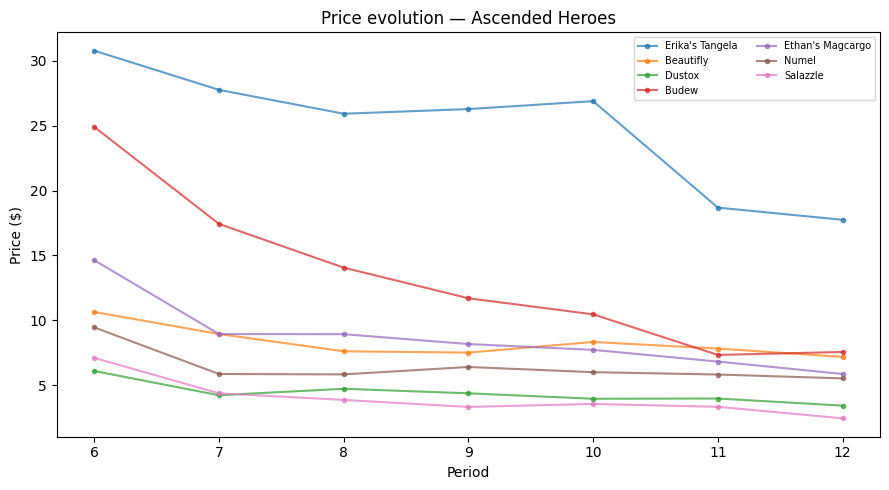

In [97]:
f = plot_price_trajectories(panel_df, set_name="Ascended Heroes", n_cards=7)
f.show()

/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_1280/583979369.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  r.show()


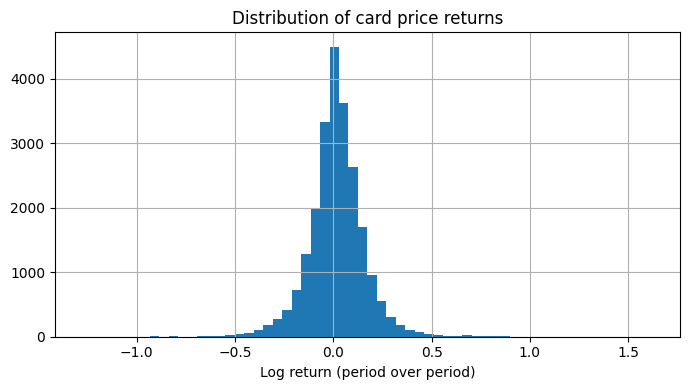

In [98]:
r = plot_return_distribution(panel_df)
r.show()

/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_1280/2851027809.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  s.show()


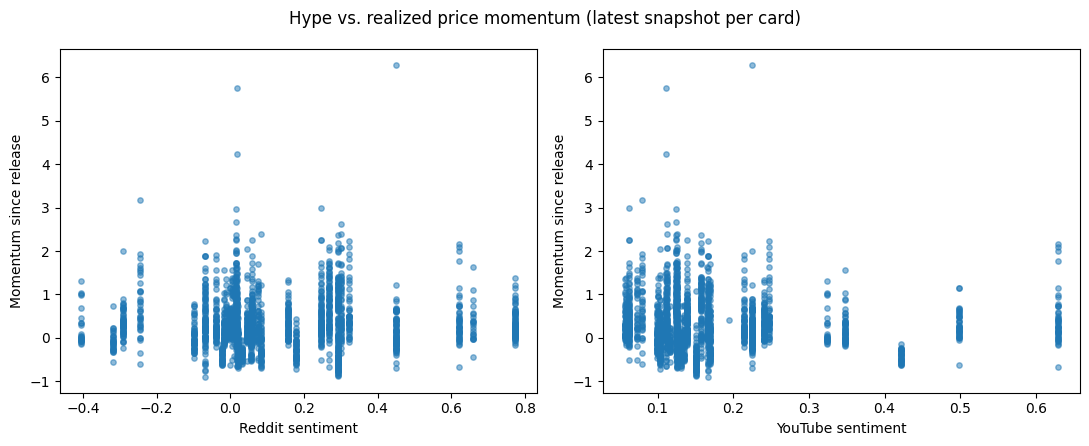

In [99]:
s = plot_sentiment_vs_momentum(model_df)
s.show()

/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_1280/2186112276.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


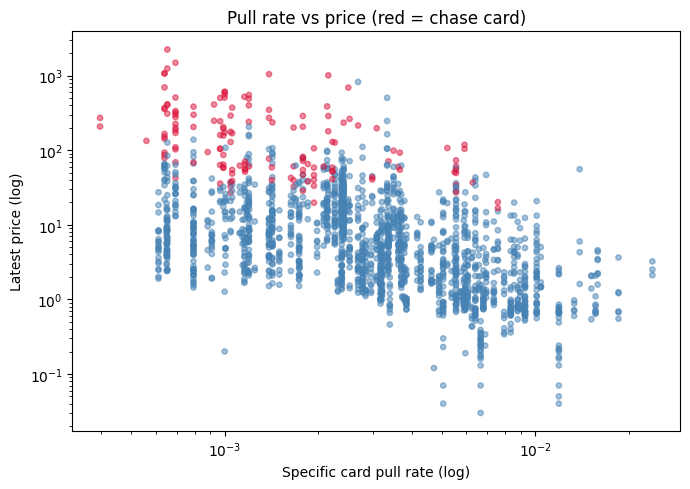

In [100]:
p = plot_pull_rate_vs_price(model_df)
p.show()

# MODELING

In [101]:
def prepare_model_frame(model_df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows without a target (last period per card, no 'next' to predict)
    and rows with missing features; z-score numeric features for sane priors."""
    df = model_df.dropna(subset=[TARGET_COL]).copy()
    df = df.dropna(subset=[c for c in FEATURE_COLS if c in df.columns])
    for c in FEATURE_COLS:
        if c in df.columns:
            df[c + "_z"] = (df[c] - df[c].mean()) / (df[c].std() + 1e-9)
    df["set_idx"], set_labels = pd.factorize(df[GROUP_COL])
    return df, set_labels
 
 
def build_pymc_model(df: pd.DataFrame):
    """
    Hierarchical partial-pooling model:
      target_next_log_return ~ Normal(mu, sigma)
      mu = (alpha_global + alpha_set[set]) + sum(beta_j * feature_j)
      alpha_set ~ Normal(0, tau)   <- sets are pooled toward the global mean
    This lets sets with few cards borrow strength from the overall trend
    instead of overfitting to noise.
    """
    import pymc as pm
 
    feat_cols_z = [c + "_z" for c in FEATURE_COLS if (c + "_z") in df.columns]
    X = df[feat_cols_z].values
    y = df[TARGET_COL].values
    set_idx = df["set_idx"].values
    n_sets = df["set_idx"].nunique()
 
    with pm.Model() as model:
        alpha_global = pm.Normal("alpha_global", mu=0, sigma=0.1)
        tau = pm.HalfNormal("tau", sigma=0.1)
        alpha_set = pm.Normal("alpha_set", mu=0, sigma=tau, shape=n_sets)
 
        betas = pm.Normal("betas", mu=0, sigma=0.5, shape=X.shape[1])
        sigma = pm.HalfNormal("sigma", sigma=0.5)
 
        mu = alpha_global + alpha_set[set_idx] + pm.math.dot(X, betas)
        pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
 
    return model
 
 
def fit_and_summarize(model):
    import pymc as pm
    import arviz as az
 
    with model:
        idata = pm.sample(1000, tune=1000, target_accept=0.9)
    print(az.summary(idata, var_names=["alpha_global", "tau", "betas", "sigma"]))
    return idata

In [102]:
FEATURE_COLS = [
    "pullRate", "specificCardPullRate", "pokemonPopularity", "costPerPull",
    "ebay_marketIndex", "ebay_mic_liquidityScore", "ebay_mic_momentumScore",
    "ebay_mic_stabilityScore", "ebay_mic_freshnessScore",
    "rd_redditSentiment", "rd_weightedEngagement",
    "yt_youtubeSentiment", "yt_weightedEngagement90",
    "roll_mean_3", "roll_std_3", "momentum_since_start", "log_return",
]
TARGET_COL = "target_next_log_return"
GROUP_COL = "setName"

In [103]:
model_df = pd.read_csv("data/output/model_ready_panel.csv")
df, set_labels = prepare_model_frame(model_df)
print(f"Model-ready rows: {len(df)}, sets: {len(set_labels)}")
pm_model = build_pymc_model(df)
idata = fit_and_summarize(pm_model)

Initializing NUTS using jitter+adapt_diag...


Model-ready rows: 21210, sets: 35


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_global, tau, alpha_set, betas, sigma]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 284 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                  mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha_global    0.0142   0.0032   0.0091    0.019      392      698  1.01   0.00016  0.00012
tau             0.0166    0.003    0.012    0.022     1169     1789  1.00   8.6e-05  6.6e-05
betas[0]       0.00714  0.00141   0.0048   0.0094     1668     2283  1.00   3.5e-05  2.4e-05
betas[1]       0.00297  0.00169  0.00025   0.0056     1933     2390  1.00   3.8e-05  2.6e-05
betas[2]       0.00565  0.00108   0.0039   0.0074     2839     2623  1.00     2e-05  1.4e-05
betas[3]      -0.00078  0.00176  -0.0036    0.002     1686     2563  1.00   4.3e-05    3e-05
betas[4]          0.02     0.36    -0.56      0.6      307      513  1.01     0.021    0.014
betas[5]         -0.02     0.33    -0.56      0.5      307      517  1.01     0.019    0.013
betas[6]            -0    0.117    -0.19     0.18      307      524  1.01    0.0067   0.0046
betas[7]        -0.001    0.052   -0.084     0.08      307      517  1